# 03 · Baselines — Logistic Regression & From-Scratch Single-Layer Perceptron

**Owner:** Riya (Model Lead)

Two reference models the MLP must match or beat:

| Model | Implementation |
|---|---|
| Logistic Regression | scikit-learn (`LogisticRegression(max_iter=1000, random_state=42)`) |
| Single-Layer Perceptron | **pure NumPy, from scratch** — `src/numpy_perceptron.py` (mandatory from-scratch component) |

> **Test-set policy.** The course rules say *"report metrics on the test set only once"*. This notebook therefore evaluates on the **validation** split. Both baselines are saved to `models/baselines/` and scored on the test set together with the MLP in a single run in notebook 07.

In [1]:
# ── Environment setup: works on Google Colab (Drive) AND locally (VS Code / Jupyter) ──
import os, sys

try:
    from google.colab import drive  # only importable inside a Colab runtime
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/telco-churn-dashboard'
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    _cwd = os.path.abspath(os.getcwd())
    PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)                      # every relative path is now project-relative
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)        # lets us `import src...`
print('Project root:', PROJECT_ROOT, '| running on Colab:', IN_COLAB)

Project root: /Users/friday/Desktop/nndl/telco-churn-dashboard | running on Colab: False


In [2]:
# Colab already ships torch, numpy, pandas, scikit-learn, matplotlib and seaborn.
# Install the extras once per Colab session (skipped automatically when running locally).
if IN_COLAB:
    %pip install -q imbalanced-learn shap fastapi uvicorn jinja2 python-multipart joblib

In [3]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from src import config
from src import plotting as P
from src.data_preprocessing import load_splits
from src.metrics import classification_metrics, metrics_table, to_markdown_table
from src.numpy_perceptron import NumpyPerceptron

config.set_seed(config.SEED)
P.apply_style()
splits = load_splits()            # include_test=False -> X_test is not even loaded
X_train, y_train, X_val, y_val = splits.X_train, splits.y_train, splits.X_val, splits.y_val
BASELINE_DIR = config.MODELS_DIR / 'baselines'
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
print('train', X_train.shape, '| val', X_val.shape, '| test loaded?', splits.X_test is not None)

train (4225, 40) | val (1409, 40) | test loaded? False


## 1 · Baseline 1 — Logistic Regression (scikit-learn)
$P(\text{churn}\mid x) = \sigma(w^\top x + b)$, fitted by L-BFGS with scikit-learn's default L2 penalty ($C = 1$).

In [4]:
logreg = LogisticRegression(max_iter=1000, random_state=config.SEED)
logreg.fit(X_train, y_train)
val_prob_lr = logreg.predict_proba(X_val)[:, 1]
lr_metrics = classification_metrics(y_val, val_prob_lr, threshold=0.5)
joblib.dump(logreg, BASELINE_DIR / 'logreg.pkl')
pd.Series(lr_metrics).to_frame('Logistic Regression (validation)').T.round(4)

,precision,recall,f1,pr_auc,roc_auc,accuracy,threshold,tp,fp,tn,fn,n_flagged
Logistic Regression (validation),0.6568,0.5321,0.5879,0.6421,0.836,0.802,0.5,199.0,104.0,931.0,175.0,303.0


## 2 · Baseline 2 — Single-Layer Perceptron in pure NumPy

**Forward pass** $\;z = XW + b,\quad \hat y = \sigma(z) = \dfrac{1}{1+e^{-z}}$

**Loss (BCE)** $\;L = -\dfrac{1}{m}\sum_i \big[y_i\log\hat y_i + (1-y_i)\log(1-\hat y_i)\big]$

**Back-propagation (chain rule).** $\dfrac{\partial L}{\partial \hat y_i}=\dfrac{1}{m}\dfrac{\hat y_i-y_i}{\hat y_i(1-\hat y_i)}$ and $\dfrac{\partial \hat y_i}{\partial z_i}=\hat y_i(1-\hat y_i)$, so the sigmoid derivative cancels and $\dfrac{\partial L}{\partial z_i}=\dfrac{1}{m}(\hat y_i-y_i)$. With $\partial z/\partial W = X$ and $\partial z/\partial b = 1$:

$$\frac{\partial L}{\partial W} = \frac{1}{m} X^\top(\hat y - y), \qquad \frac{\partial L}{\partial b} = \frac{1}{m}\sum_i(\hat y_i - y_i)$$

**Update** $\;W \leftarrow W - \eta\,\partial L/\partial W,\quad b \leftarrow b - \eta\,\partial L/\partial b$ — once per mini-batch of 64 shuffled rows.

### 2.1 Gradient check — proving the hand-derived gradients are right
We compare the analytic gradient with a central finite difference $\big[L(\theta+\varepsilon)-L(\theta-\varepsilon)\big]/2\varepsilon$ for every one of the 41 parameters.

In [5]:
check_model = NumpyPerceptron(n_features=X_train.shape[1], seed=config.SEED)
rel_error = check_model.gradient_check(X_train[:100], y_train[:100])
print(f'Max relative error, analytic vs numerical gradient: {rel_error:.2e}')
assert rel_error < 1e-6, 'gradient formula is wrong!'
print('Gradient check passed: dL/dW = X^T(y_hat - y)/m and dL/db = mean(y_hat - y) are correct.')

Max relative error, analytic vs numerical gradient: 2.40e-10
Gradient check passed: dL/dW = X^T(y_hat - y)/m and dL/db = mean(y_hat - y) are correct.


### 2.2 Choosing the learning rate η on the validation set
Mini-batch gradient descent with a constant η does not settle at the minimum: every update uses a noisy 64-row estimate of the gradient, so the parameters keep "bouncing" with an amplitude proportional to η. We train for 300 epochs with four learning rates and keep the one with the **lowest final validation BCE** (a validation-set decision — the test set is untouched).

In [6]:
lr_grid = [0.5, 0.1, 0.05, 0.01]
sweep = {}
for eta in lr_grid:
    model = NumpyPerceptron(n_features=X_train.shape[1], learning_rate=eta, n_epochs=300,
                            batch_size=64, seed=config.SEED)
    sweep[eta] = model.fit(X_train, y_train, X_val, y_val)

lr_table = pd.DataFrame({
    eta: {'final train BCE': m.history.train_loss[-1], 'final val BCE': m.history.val_loss[-1],
          'std of last 50 train BCE': float(np.std(m.history.train_loss[-50:]))}
    for eta, m in sweep.items()}).T.rename_axis('learning rate η')
best_eta = float(lr_table['final val BCE'].idxmin())
perceptron = sweep[best_eta]
perceptron.save(BASELINE_DIR / 'perceptron.npz')
print(f'Selected η = {best_eta}')
lr_table.round(4)

Selected η = 0.01


,final train BCE,final val BCE,std of last 50 train BCE
learning rate η,,,
0.50,0.4151,0.4366,0.1736
0.10,0.4082,0.4293,0.0080
0.05,0.4082,0.4292,0.0021
0.01,0.4089,0.4288,0.0002


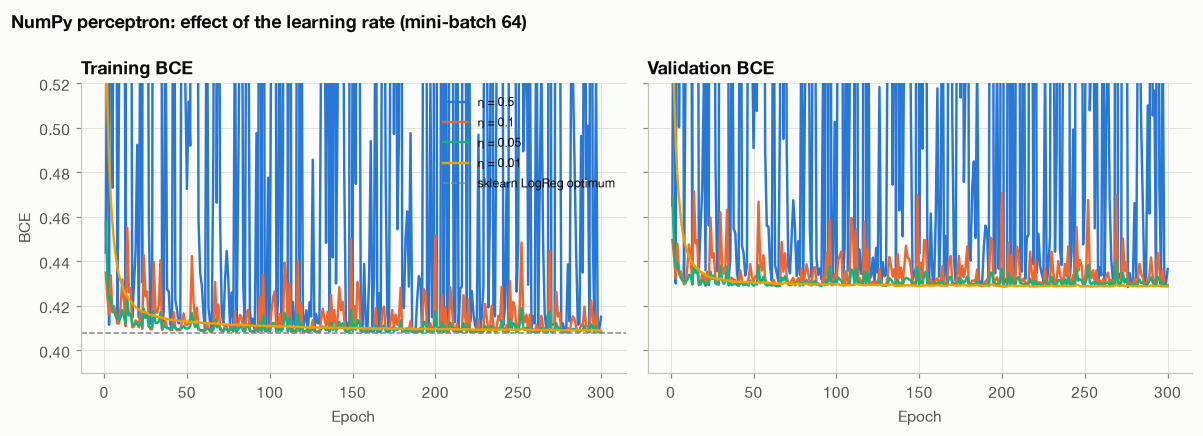

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for color, (eta, m) in zip(P.SERIES, sweep.items()):
    epochs = np.arange(1, len(m.history.train_loss) + 1)
    axes[0].plot(epochs, m.history.train_loss, color=color, linewidth=1.6, label=f'η = {eta}')
    axes[1].plot(epochs, m.history.val_loss, color=color, linewidth=1.6, label=f'η = {eta}')
lr_ref = NumpyPerceptron.bce_loss(logreg.predict_proba(X_train)[:, 1], y_train)
axes[0].axhline(lr_ref, color=P.MUTED, linestyle='--', linewidth=1, label='sklearn LogReg optimum')
axes[0].set(title='Training BCE', xlabel='Epoch', ylabel='BCE')
axes[1].set(title='Validation BCE', xlabel='Epoch')
axes[0].set_ylim(0.39, 0.52)
axes[0].legend(fontsize=8)
fig.suptitle('NumPy perceptron: effect of the learning rate (mini-batch 64)', x=0.01, ha='left',
             fontweight='bold')
fig.tight_layout()
P.save_figure(fig, config.PLOTS_DIR / 'perceptron_learning_rate.png')
plt.show()

Large η (0.5) makes the loss jump around well above the optimum; small η converges smoothly to essentially the **same loss as scikit-learn's solver** (dashed line). This is the classic learning-rate trade-off: too large → oscillation/noise, too small → slow convergence.

In [8]:
val_prob_slp = perceptron.predict_proba(X_val)
slp_metrics = classification_metrics(y_val, val_prob_slp, threshold=0.5)
pd.Series(slp_metrics).to_frame(f'Perceptron η={best_eta} (validation)').T.round(4)

,precision,recall,f1,pr_auc,roc_auc,accuracy,threshold,tp,fp,tn,fn,n_flagged
Perceptron η=0.01 (validation),0.6667,0.5348,0.5935,0.64,0.8348,0.8055,0.5,200.0,100.0,935.0,174.0,300.0


## 3 · Sanity check — the two baselines are the same model family
A sigmoid single-layer perceptron trained on BCE *is* logistic regression; only the optimiser differs (our mini-batch GD vs. L-BFGS with a small L2 penalty). Their **predictions** should therefore be nearly identical — but their individual **weights** need not be, because some inputs are strongly collinear.

In [9]:
w_slp, w_lr = perceptron.W.ravel(), logreg.coef_.ravel()
print(f'Correlation of predicted validation probabilities: {np.corrcoef(val_prob_slp, val_prob_lr)[0, 1]:.4f}')
print(f'Correlation of the 40 learned weights            : {np.corrcoef(w_slp, w_lr)[0, 1]:.3f}')
coef = pd.DataFrame({'NumPy perceptron W': w_slp, 'sklearn LogReg w': w_lr}, index=splits.feature_names)
coef.reindex(coef['sklearn LogReg w'].abs().sort_values(ascending=False).index).head(10).round(3)

Correlation of predicted validation probabilities: 0.9984
Correlation of the 40 learned weights            : 0.875


,NumPy perceptron W,sklearn LogReg w
tenure,-0.930,-1.315
Contract_Two year,-0.798,-0.905
Contract_Month-to-month,0.577,0.625
InternetService_DSL,-0.454,-0.621
TotalCharges,0.163,0.597
InternetService_Fiber optic,0.229,0.505
MonthlyCharges,0.318,-0.359
MultipleLines_No,-0.372,-0.329
PaperlessBilling_Yes,0.310,0.317
OnlineSecurity_No internet service,-0.194,-0.286


## 4 · Baseline comparison table (validation split, threshold 0.5)

In [10]:
baseline_table = metrics_table(
    {'Logistic Regression': lr_metrics, 'Single-Layer Perceptron': slp_metrics},
    extra_columns={'Logistic Regression': {'Implementation': 'scikit-learn'},
                   'Single-Layer Perceptron': {'Implementation': 'Pure NumPy (from scratch)'}},
)
baseline_table.to_csv(config.RESULTS_DIR / 'baselines_val.csv')
print(to_markdown_table(baseline_table))
baseline_table

| Model | Implementation | Precision | Recall | F1 (Churn) | PR-AUC | ROC-AUC |
|---|---|---|---|---|---|---|
| Logistic Regression | scikit-learn | 0.6568 | 0.5321 | 0.5879 | 0.6421 | 0.8360 |
| Single-Layer Perceptron | Pure NumPy (from scratch) | 0.6667 | 0.5348 | 0.5935 | 0.6400 | 0.8348 |

,Implementation,Precision,Recall,F1 (Churn),PR-AUC,ROC-AUC
Model,,,,,,
Logistic Regression,scikit-learn,0.6568,0.5321,0.5879,0.6421,0.8360
Single-Layer Perceptron,Pure NumPy (from scratch),0.6667,0.5348,0.5935,0.6400,0.8348


### Interpretation
* Both baselines reach **PR-AUC ≈ 0.64 and ROC-AUC ≈ 0.84** on validation — far above the 0.265 PR-AUC of random guessing. A *linear* model already captures most of the signal (contract, tenure, internet type), so logistic regression is a strong bar for the MLP.
* The from-scratch perceptron matches scikit-learn almost exactly once η is chosen well (same PR-AUC to two decimals, near-identical predicted probabilities) — independent evidence that our forward pass, loss and gradients are implemented correctly.
* The *weights* differ most on `TotalCharges` and `MonthlyCharges` (even the sign of `MonthlyCharges` flips). Because `TotalCharges ≈ tenure × MonthlyCharges`, many different weight combinations give almost the same predictions (**collinearity**); scikit-learn's L2 penalty and our different optimiser simply settle on different members of that family. Individual linear coefficients are therefore not a reliable importance measure here — one reason we use SHAP in notebook 07.
* At the default 0.5 threshold both have recall ≈ 0.53: they miss roughly half of the churners. The threshold is revisited on business-cost grounds in notebook 06.